In [1]:
from Bio import SeqIO
from Bio.Blast import NCBIWWW, NCBIXML
import csv

In [2]:
records = records = list(SeqIO.parse("GCF_000005845.2_ASM584v2_protein.faa", "fasta"))
first5 = records[:5]
SeqIO.write(first5, "first5_orfs.fna", "fasta")
print(f"Extracted {len(first5)} ORFs.")

Extracted 5 ORFs.


In [3]:
for i, record in enumerate(first5, start=1):

    print(f"Running BLAST for {record.id}")

    result_handle = NCBIWWW.qblast("blastp", "nr", record.seq)

    with open(f"blast_result_{i}.xml", "w") as out_handle:
        out_handle.write(result_handle.read())

    result_handle.close()

    print(f"Saved blast_result_{i}.xml")

Running BLAST for NP_414542.1
Saved blast_result_1.xml
Running BLAST for NP_414543.1
Saved blast_result_2.xml
Running BLAST for NP_414544.1
Saved blast_result_3.xml
Running BLAST for NP_414545.1
Saved blast_result_4.xml
Running BLAST for NP_414546.1
Saved blast_result_5.xml


In [4]:
import pandas as pd
from Bio.Blast import NCBIXML

rows = []

for i in range(1, 6):
    filename = f"blast_result_{i}.xml"

    with open(filename) as result_handle:
        blast_record = NCBIXML.read(result_handle)

        if len(blast_record.alignments) > 0:

            alignment = blast_record.alignments[0]
            hsp = alignment.hsps[0]

            identity = (hsp.identities / hsp.align_length) * 100

            rows.append({
                "ORF": blast_record.query,
                "Top Hit": alignment.hit_def,
                "E-value": hsp.expect,
                "Identity (%)": round(identity, 2),
                "Function": alignment.hit_def
            })

df = pd.DataFrame(rows)

df


,ORF,Top Hit,E-value,Identity (%),Function
0,unnamed protein product,thr operon leader peptide [Escherichia coli] >...,2.041070e-02,100.0,thr operon leader peptide [Escherichia coli] >...
1,unnamed protein product,"homoserine dehydrogenase, partial [Escherichia...",0.000000e+00,100.0,"homoserine dehydrogenase, partial [Escherichia..."
2,unnamed protein product,MULTISPECIES: homoserine kinase [Enterobacteri...,0.000000e+00,100.0,MULTISPECIES: homoserine kinase [Enterobacteri...
3,unnamed protein product,MULTISPECIES: threonine synthase [Enterobacter...,0.000000e+00,100.0,MULTISPECIES: threonine synthase [Enterobacter...
4,unnamed protein product,MULTISPECIES: DUF2502 domain-containing protei...,3.032840e-63,100.0,MULTISPECIES: DUF2502 domain-containing protei...


In [6]:
filter_df = df[(df["E-value"] < 1e-10) & (df["Identity (%)"] >40)]
filter_df

,ORF,Top Hit,E-value,Identity (%),Function
1,unnamed protein product,"homoserine dehydrogenase, partial [Escherichia...",0.000000e+00,100.0,"homoserine dehydrogenase, partial [Escherichia..."
2,unnamed protein product,MULTISPECIES: homoserine kinase [Enterobacteri...,0.000000e+00,100.0,MULTISPECIES: homoserine kinase [Enterobacteri...
3,unnamed protein product,MULTISPECIES: threonine synthase [Enterobacter...,0.000000e+00,100.0,MULTISPECIES: threonine synthase [Enterobacter...
4,unnamed protein product,MULTISPECIES: DUF2502 domain-containing protei...,3.032840e-63,100.0,MULTISPECIES: DUF2502 domain-containing protei...


In [7]:
filter_df.to_csv("final_annotation_table.csv", index=False)
print("successfully saved")

successfully saved


In [9]:
def categorize(function):
    function = function.lower()

    if "homoserine" in function:
        return "Amino acid biosynthesis"

    elif "threonine" in function:
        return "Amino acid biosynthesis"

    elif "duf" in function:
        return "Unknown function"

    else:
        return "Other"

filter_df["Category"] = filter_df["Function"].apply(categorize)

filter_df


,ORF,Top Hit,E-value,Identity (%),Function,Category
1,unnamed protein product,"homoserine dehydrogenase, partial [Escherichia...",0.000000e+00,100.0,"homoserine dehydrogenase, partial [Escherichia...",Amino acid biosynthesis
2,unnamed protein product,MULTISPECIES: homoserine kinase [Enterobacteri...,0.000000e+00,100.0,MULTISPECIES: homoserine kinase [Enterobacteri...,Amino acid biosynthesis
3,unnamed protein product,MULTISPECIES: threonine synthase [Enterobacter...,0.000000e+00,100.0,MULTISPECIES: threonine synthase [Enterobacter...,Amino acid biosynthesis
4,unnamed protein product,MULTISPECIES: DUF2502 domain-containing protei...,3.032840e-63,100.0,MULTISPECIES: DUF2502 domain-containing protei...,Unknown function


In [11]:
category_counts = filter_df["Category"].value_counts()

category_counts


Category
Amino acid biosynthesis    3
Unknown function           1
Name: count, dtype: int64

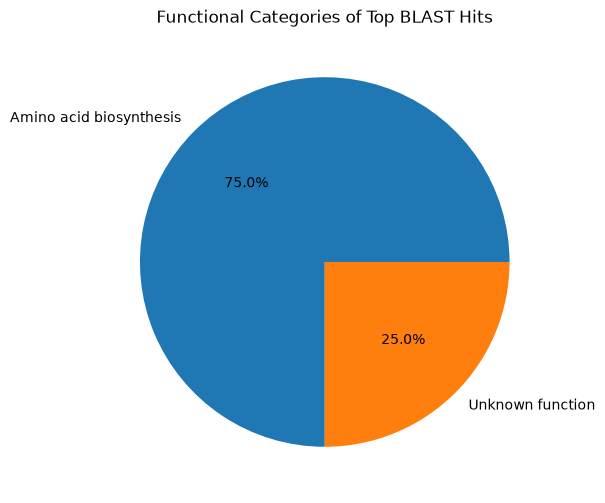

In [13]:
import matplotlib.pyplot as plt

category_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title("Functional Categories of Top BLAST Hits")
plt.ylabel("")
plt.savefig("functional_categories_pie.png")
plt.show()


